# 🤖 06c — Entrenamiento v3 + Evaluación por Evento
## Cambios respecto a 06b

1. **Lee `features_*_v3.parquet`** — con yaw_cable lead=72h y pitch_bat sin temperatura absoluta
2. **Evaluación por evento**: en lugar de medir fila a fila, mide si cada fallo real tuvo al menos una alerta en las N horas previas — es la métrica real de un sistema de mantenimiento predictivo
3. **Threshold adaptativo por familia** basado en la curva PR real


In [6]:
import os, json, pickle, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import precision_recall_curve, roc_auc_score, confusion_matrix
warnings.filterwarnings('ignore')

base_dir   = os.path.dirname(os.getcwd())
silver_dir = os.path.join(base_dir, 'data', 'silver')
models_dir = os.path.join(base_dir, 'data', 'models')
os.makedirs(models_dir, exist_ok=True)

FAULT_FAMILIES = {
    'yaw_cable':   {'lead_hours': 72,  'color': '#378ADD'},
    'generator':   {'lead_hours': 120, 'color': '#D85A30'},
    'brake_hydro': {'lead_hours': 120, 'color': '#BA7517'},
    'pitch_bat':   {'lead_hours': 336, 'color': '#1D9E75'},
}

LGBM_PARAMS = {
    'n_estimators':     1000,
    'class_weight':     'balanced',
    'learning_rate':    0.05,
    'num_leaves':       63,
    'min_child_samples':20,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,
}
TRAIN_RATIO = 0.80
print('✅ Config cargada')


✅ Config cargada


In [7]:
# ==============================================================================
# EVALUACIÓN POR EVENTO — la métrica real
# ==============================================================================
def evaluate_by_event(test_df, y_prob, family, threshold, lead_hours):
    """
    Para cada fallo real en el período de test, comprueba si hubo al menos
    una alerta (prob >= threshold) en las `lead_hours` horas previas.
    
    Event Recall = fallos detectados / fallos totales en test
    Esta es la métrica que importa operativamente.
    """
    cfg = FAULT_FAMILIES[family]
    df  = test_df[['timestamp']].copy()
    df['prob']      = y_prob
    df['is_pre']    = test_df[f'is_pre_{family}'].values
    df['hours_to']  = test_df[f'hours_to_{family}'].values if f'hours_to_{family}' in test_df.columns else np.nan
    df = df.sort_values('timestamp').reset_index(drop=True)

    # Detectar inicio de cada ventana pre-fallo (transición False→True)
    is_pre = df['is_pre'].astype(bool)
    fault_starts = df['timestamp'][is_pre & ~is_pre.shift(1, fill_value=False)].tolist()

    detected = 0
    total    = len(fault_starts)
    details  = []

    for fault_start in fault_starts:
        # Ventana = desde fault_start hasta el fallo real (lead_hours después)
        window_end   = fault_start + pd.Timedelta(hours=lead_hours)
        window_mask  = (df['timestamp'] >= fault_start) & (df['timestamp'] < window_end)
        max_prob_win = df.loc[window_mask, 'prob'].max() if window_mask.any() else 0.0
        was_detected = max_prob_win >= threshold
        if was_detected:
            detected += 1
        details.append({
            'fault_start': fault_start,
            'max_prob':    round(float(max_prob_win), 3),
            'detected':    was_detected,
        })

    event_recall = detected / total if total > 0 else 0.0
    return {
        'event_recall':      round(event_recall, 4),
        'events_detected':   detected,
        'events_total':      total,
        'details':           details,
    }

print('Función evaluate_by_event definida')


Función evaluate_by_event definida


In [8]:
# ==============================================================================
# FUNCIÓN DE ENTRENAMIENTO v3
# ==============================================================================
def train_family_v3(family, params=LGBM_PARAMS, train_ratio=TRAIN_RATIO, verbose=True):
    cfg        = FAULT_FAMILIES[family]
    target_col = f'is_pre_{family}'
    hours_col  = f'hours_to_{family}'

    path = os.path.join(silver_dir, f'features_{family}_v3.parquet')
    if not os.path.exists(path):
        raise FileNotFoundError(f'No encontrado: features_{family}_v3.parquet\nEjecuta 05c primero')

    df = pd.read_parquet(path).dropna(subset=[target_col]).sort_values('timestamp').reset_index(drop=True)
    feature_cols = [c for c in df.columns if c not in ['timestamp', target_col, hours_col]]

    cutoff  = df['timestamp'].quantile(train_ratio)
    train   = df[df['timestamp'] <  cutoff].copy()
    test    = df[df['timestamp'] >= cutoff].copy()

    X_train = train[feature_cols].fillna(0)
    y_train = train[target_col].astype(int)
    X_test  = test[feature_cols].fillna(0)
    y_test  = test[target_col].astype(int)

    if verbose:
        print(f'\n{"="*60}')
        print(f'  {family.upper()}  [v3]  lead={cfg["lead_hours"]}h')
        print(f'{"="*60}')
        print(f'  Train: {len(train):>7,} | {y_train.sum():>6,} pos ({100*y_train.mean():.1f}%)')
        print(f'  Test:  {len(test):>7,} | {y_test.sum():>6,} pos ({100*y_test.mean():.1f}%)')
        print(f'  Features: {len(feature_cols)}')

    t0    = time.time()
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(100, verbose=False),
                         lgb.log_evaluation(200 if verbose else 0)])
    y_prob = model.predict_proba(X_test)[:, 1]

    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = float('nan')

    # Threshold: elegir el que maximiza event_recall con precision_row >= 0.10
    prec_c, rec_c, thr_c = precision_recall_curve(y_test, y_prob)
    # Empezar desde threshold que tenga precision_row > 10% para no disparar alarmas constantemente
    valid = [(t, r) for p, r, t in zip(prec_c, rec_c, thr_c) if p >= 0.10]
    if valid:
        best_threshold = min(valid, key=lambda x: -x[1])[0]  # menor threshold que mantiene precision>=10%
    else:
        best_threshold = 0.20

    y_pred = (y_prob >= best_threshold).astype(int)
    cm     = confusion_matrix(y_test, y_pred)

    from sklearn.metrics import classification_report
    report = classification_report(y_test, y_pred, target_names=['Normal','Pre-fallo'], output_dict=True)

    # Evaluación por evento
    ev = evaluate_by_event(test, y_prob, family, best_threshold, cfg['lead_hours'])

    metrics = {
        'family':         family,
        'version':        'v3',
        'threshold':      round(float(best_threshold), 3),
        'lead_hours':     cfg['lead_hours'],
        'auc_roc':        round(auc, 4),
        'precision_row':  round(report['Pre-fallo']['precision'], 4),
        'recall_row':     round(report['Pre-fallo']['recall'],    4),
        'f1_row':         round(report['Pre-fallo']['f1-score'],  4),
        'event_recall':   ev['event_recall'],
        'events_detected':ev['events_detected'],
        'events_total':   ev['events_total'],
        'tn': int(cm[0,0]), 'fp': int(cm[0,1]),
        'fn': int(cm[1,0]), 'tp': int(cm[1,1]),
        'best_iteration': int(model.best_iteration_) if hasattr(model,'best_iteration_') else params['n_estimators'],
        'train_time_s':   round(time.time()-t0, 1),
    }

    if verbose:
        print(f'\n  MÉTRICAS POR FILA (threshold={best_threshold:.2f}):')
        print(f'    Precision: {metrics["precision_row"]:.3f}  Recall: {metrics["recall_row"]:.3f}  F1: {metrics["f1_row"]:.3f}')
        print(f'    AUC-ROC:   {metrics["auc_roc"]:.3f}')
        print(f'\n  MÉTRICAS POR EVENTO (la que importa operativamente):')
        print(f'    Fallos detectados: {ev["events_detected"]} / {ev["events_total"]}')
        print(f'    Event Recall:      {ev["event_recall"]:.3f}  (objetivo > 0.80)')
        print(f'\n  Matriz confusión:  TN={cm[0,0]:,}  FP={cm[0,1]:,}  FN={cm[1,0]:,}  TP={cm[1,1]:,}')
        print(f'  Árboles: {metrics["best_iteration"]}  Tiempo: {metrics["train_time_s"]}s')

    return model, metrics, train, test, X_test, y_test, y_prob, feature_cols

print('Función train_family_v3 definida')


Función train_family_v3 definida


In [9]:
# ==============================================================================
# VISUALIZACIONES
# ==============================================================================
def plot_feature_importance(model, feature_cols, family, top_n=20):
    cfg = FAULT_FAMILIES[family]
    fi  = pd.Series(model.feature_importances_, index=feature_cols).nlargest(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(10, max(6, top_n*0.35)))
    bars = ax.barh(fi.index, fi.values, color=cfg['color'], alpha=0.8)
    ax.set_xlabel('Importancia (gain)')
    ax.set_title(f'Top {top_n} features — {family} [v3]')
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, fi.values):
        ax.text(val*1.01, bar.get_y()+bar.get_height()/2, f'{val:.0f}', va='center', fontsize=8)
    plt.tight_layout()
    p = os.path.join(models_dir, f'feature_importance_{family}_v3.png')
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  Guardado: feature_importance_{family}_v3.png')


def plot_timeline_v3(test_df, y_prob, family, threshold, ev_details):
    cfg = FAULT_FAMILIES[family]
    df_p = test_df[['timestamp']].copy()
    df_p['prob']   = y_prob
    df_p['is_pre'] = test_df[f'is_pre_{family}'].values

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.fill_between(df_p['timestamp'], df_p['prob'], alpha=0.35, color=cfg['color'])
    ax.plot(df_p['timestamp'], df_p['prob'], color=cfg['color'], linewidth=0.6, alpha=0.7)
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1.2, label=f'Threshold {threshold:.2f}')

    for det in ev_details:
        color_line = 'darkgreen' if det['detected'] else 'darkred'
        ax.axvline(det['fault_start'], color=color_line, alpha=0.8, linewidth=1.5)

    # Leyenda manual
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0],[0], color='darkgreen', linewidth=2, label='Fallo DETECTADO'),
        Line2D([0],[0], color='darkred',   linewidth=2, label='Fallo PERDIDO'),
        Line2D([0],[0], color='red', linestyle='--', label=f'Threshold {threshold:.2f}'),
    ]
    ax.legend(handles=handles, loc='upper left')
    ax.set_ylim(0, 1); ax.set_ylabel('P(fallo)')
    ax.set_title(f'{family} [v3] — verde=detectado, rojo=perdido')
    ax.grid(alpha=0.2)
    plt.tight_layout()
    p = os.path.join(models_dir, f'timeline_{family}_v3.png')
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  Guardado: timeline_{family}_v3.png')

print('Visualizaciones definidas')


Visualizaciones definidas


## Modelo — `yaw_cable`


  YAW_CABLE  [v3]  lead=72h
  Train: 168,307 | 41,113 pos (24.4%)
  Test:   42,077 | 11,526 pos (27.4%)
  Features: 204

  MÉTRICAS POR FILA (threshold=0.17):
    Precision: 0.274  Recall: 1.000  F1: 0.430
    AUC-ROC:   0.544

  MÉTRICAS POR EVENTO (la que importa operativamente):
    Fallos detectados: 24 / 24
    Event Recall:      1.000  (objetivo > 0.80)

  Matriz confusión:  TN=0  FP=30,551  FN=0  TP=11,526
  Árboles: 23  Tiempo: 7.3s


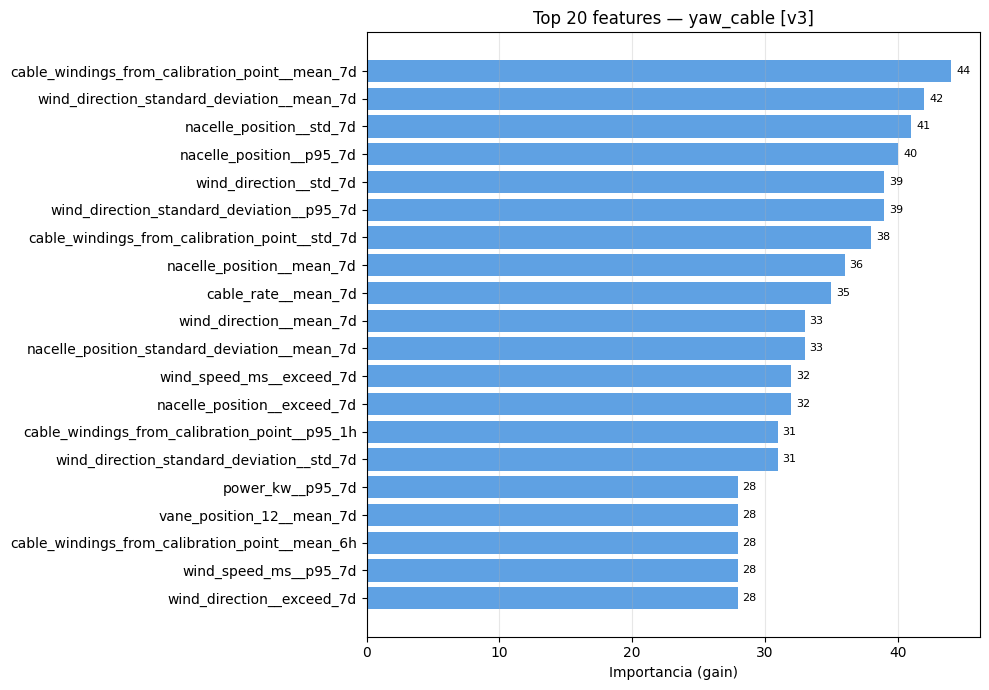

  Guardado: feature_importance_yaw_cable_v3.png


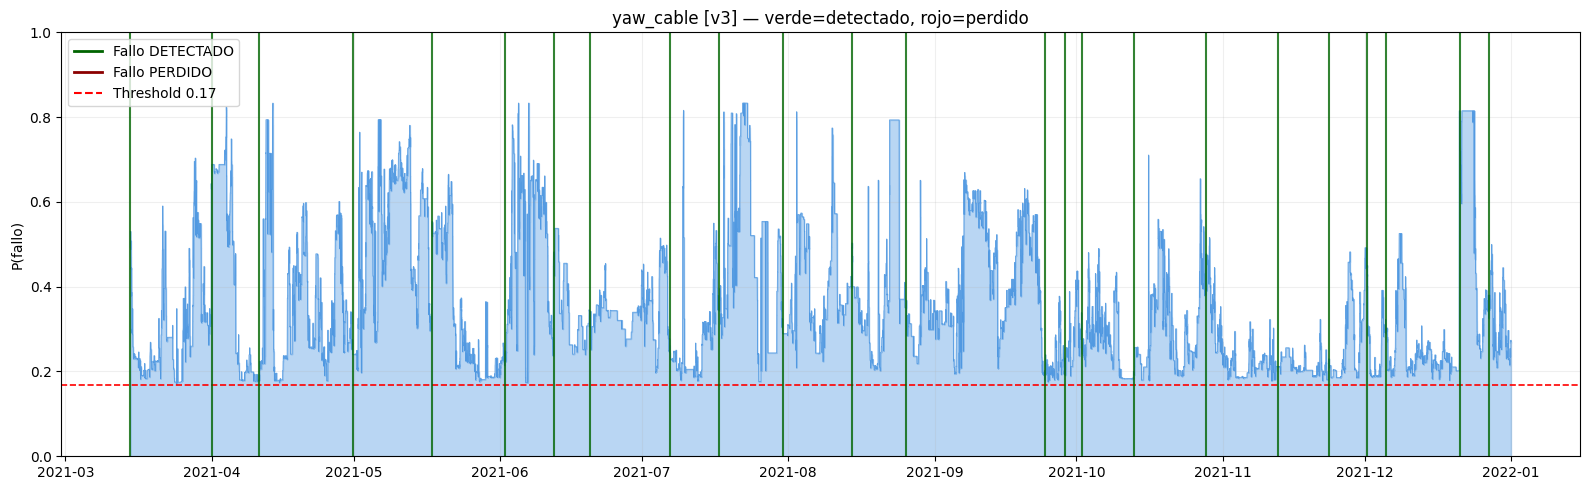

  Guardado: timeline_yaw_cable_v3.png


In [10]:
family = 'yaw_cable'

params_used = LGBM_PARAMS
result_yawcable = train_family_v3(family, params=params_used)
model_yawcable, metrics_yawcable, train_yawcable, test_yawcable, X_test_yawcable, y_test_yawcable, prob_yawcable, feats_yawcable = result_yawcable

ev_yawcable = evaluate_by_event(test_yawcable, prob_yawcable, family,
                               metrics_yawcable['threshold'], metrics_yawcable['lead_hours'])

pickle.dump(model_yawcable, open(os.path.join(models_dir, f'model_yaw_cable_v3.pkl'), 'wb'))
with open(os.path.join(models_dir, f'results_yaw_cable_v3.json'), 'w') as f:
    json.dump(metrics_yawcable, f, indent=2)
plot_feature_importance(model_yawcable, feats_yawcable, family)
plot_timeline_v3(test_yawcable, prob_yawcable, family, metrics_yawcable['threshold'], ev_yawcable['details'])


## Modelo — `generator`


  GENERATOR  [v3]  lead=120h
  Train: 168,307 | 19,384 pos (11.5%)
  Test:   42,077 |  2,888 pos (6.9%)
  Features: 357

  MÉTRICAS POR FILA (threshold=0.05):
    Precision: 0.100  Recall: 0.910  F1: 0.180
    AUC-ROC:   0.642

  MÉTRICAS POR EVENTO (la que importa operativamente):
    Fallos detectados: 4 / 4
    Event Recall:      1.000  (objetivo > 0.80)

  Matriz confusión:  TN=15,548  FP=23,641  FN=261  TP=2,627
  Árboles: 56  Tiempo: 11.4s


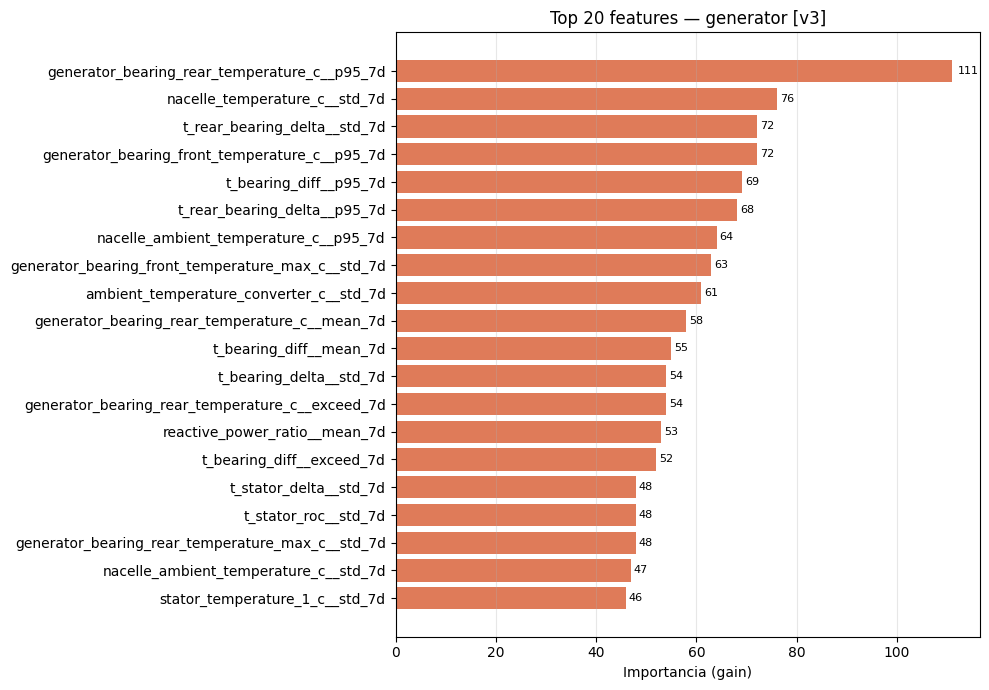

  Guardado: feature_importance_generator_v3.png


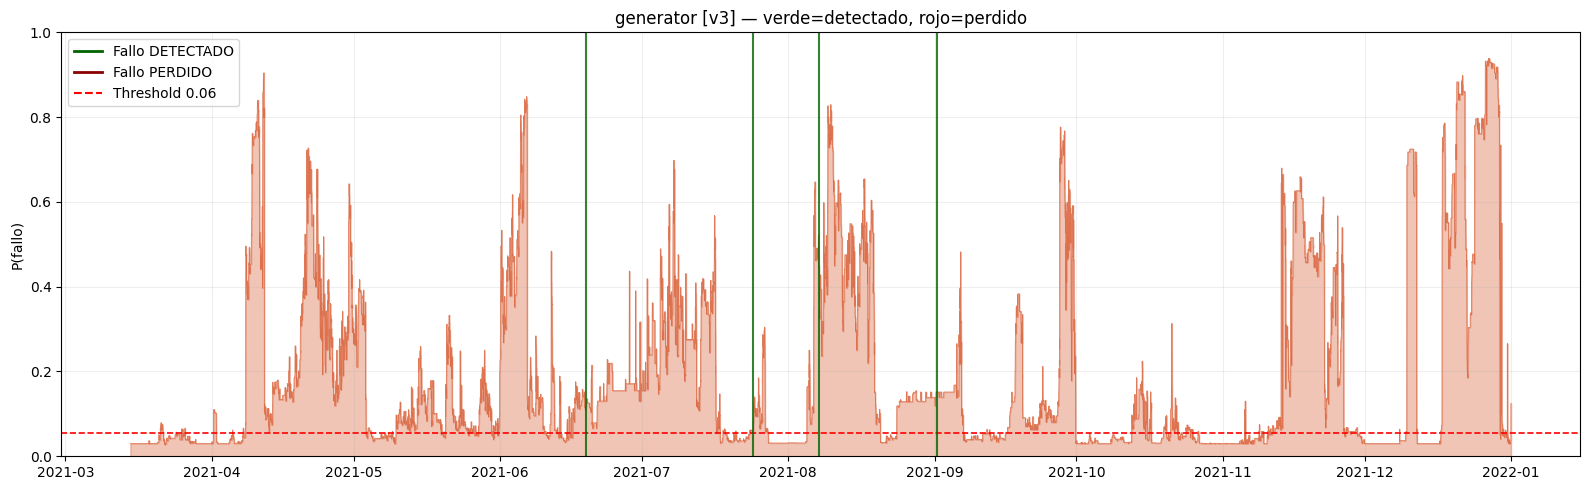

  Guardado: timeline_generator_v3.png


In [11]:
family = 'generator'

params_used = LGBM_PARAMS
result_generator = train_family_v3(family, params=params_used)
model_generator, metrics_generator, train_generator, test_generator, X_test_generator, y_test_generator, prob_generator, feats_generator = result_generator

ev_generator = evaluate_by_event(test_generator, prob_generator, family,
                               metrics_generator['threshold'], metrics_generator['lead_hours'])

pickle.dump(model_generator, open(os.path.join(models_dir, f'model_generator_v3.pkl'), 'wb'))
with open(os.path.join(models_dir, f'results_generator_v3.json'), 'w') as f:
    json.dump(metrics_generator, f, indent=2)
plot_feature_importance(model_generator, feats_generator, family)
plot_timeline_v3(test_generator, prob_generator, family, metrics_generator['threshold'], ev_generator['details'])


## Modelo — `brake_hydro`


  BRAKE_HYDRO  [v3]  lead=120h
  Train: 168,307 | 18,334 pos (10.9%)
  Test:   42,077 |  2,851 pos (6.8%)
  Features: 238

  MÉTRICAS POR FILA (threshold=0.25):
    Precision: 0.100  Recall: 0.200  F1: 0.133
    AUC-ROC:   0.478

  MÉTRICAS POR EVENTO (la que importa operativamente):
    Fallos detectados: 1 / 3
    Event Recall:      0.333  (objetivo > 0.80)

  Matriz confusión:  TN=34,088  FP=5,138  FN=2,280  TP=571
  Árboles: 55  Tiempo: 6.7s


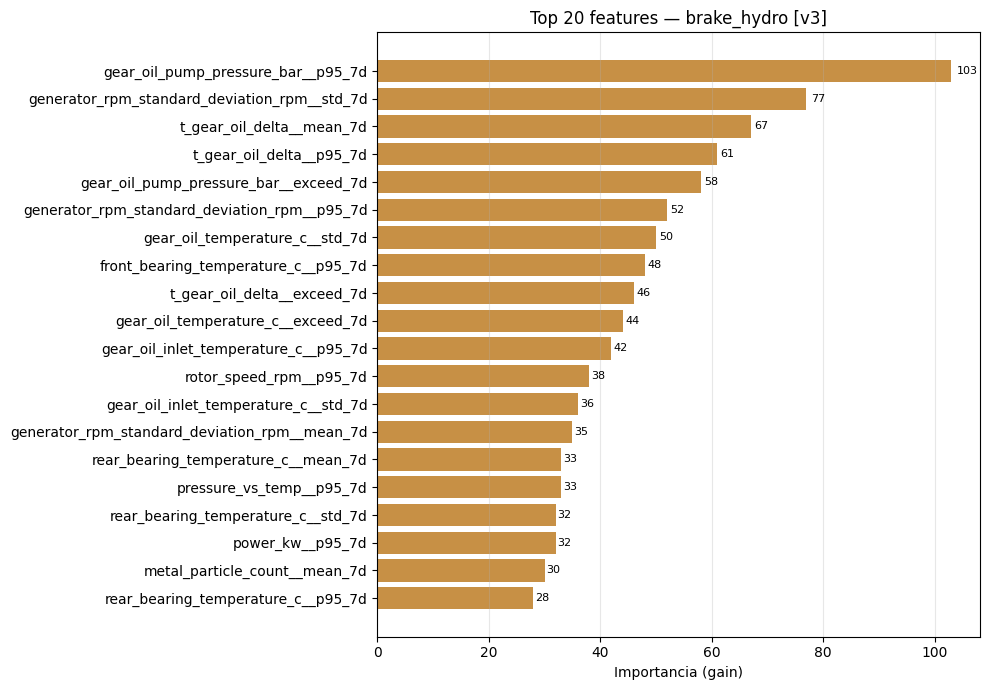

  Guardado: feature_importance_brake_hydro_v3.png


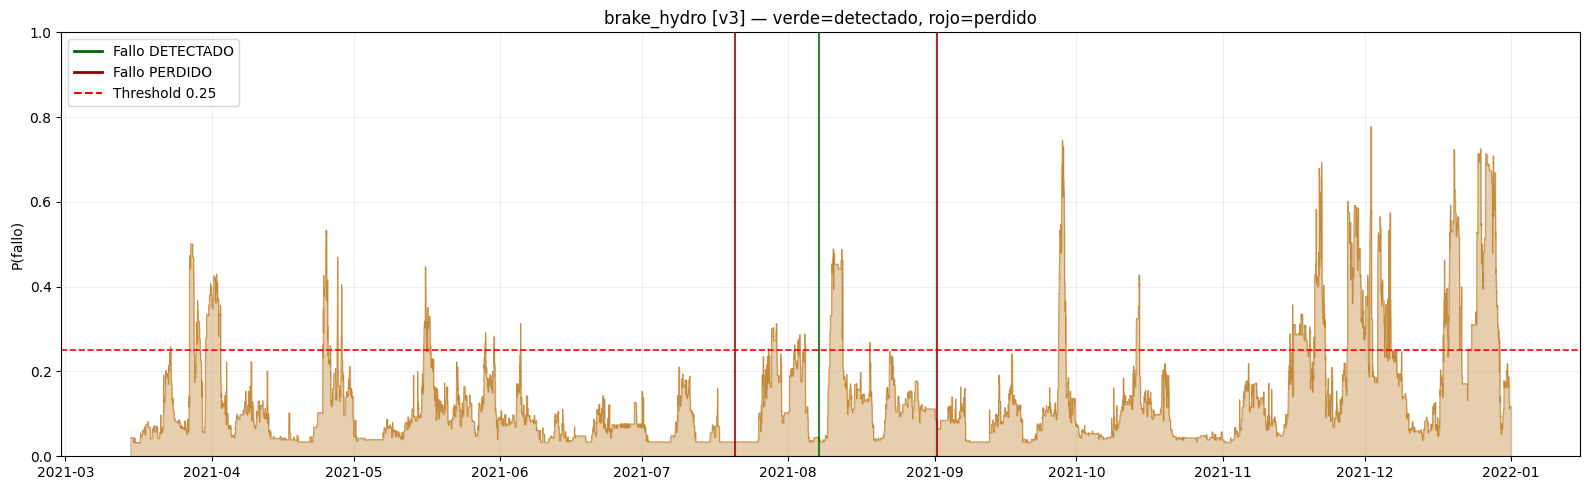

  Guardado: timeline_brake_hydro_v3.png


In [12]:
family = 'brake_hydro'

params_brakehydro = {**LGBM_PARAMS, 'num_leaves': 31, 'min_child_samples': 30}
params_used = params_brakehydro
result_brakehydro = train_family_v3(family, params=params_used)
model_brakehydro, metrics_brakehydro, train_brakehydro, test_brakehydro, X_test_brakehydro, y_test_brakehydro, prob_brakehydro, feats_brakehydro = result_brakehydro

ev_brakehydro = evaluate_by_event(test_brakehydro, prob_brakehydro, family,
                               metrics_brakehydro['threshold'], metrics_brakehydro['lead_hours'])

pickle.dump(model_brakehydro, open(os.path.join(models_dir, f'model_brake_hydro_v3.pkl'), 'wb'))
with open(os.path.join(models_dir, f'results_brake_hydro_v3.json'), 'w') as f:
    json.dump(metrics_brakehydro, f, indent=2)
plot_feature_importance(model_brakehydro, feats_brakehydro, family)
plot_timeline_v3(test_brakehydro, prob_brakehydro, family, metrics_brakehydro['threshold'], ev_brakehydro['details'])


## Modelo — `pitch_bat`


  PITCH_BAT  [v3]  lead=336h
  Train: 168,307 | 24,727 pos (14.7%)
  Test:   42,077 |  4,026 pos (9.6%)
  Features: 238

  MÉTRICAS POR FILA (threshold=0.16):
    Precision: 0.100  Recall: 1.000  F1: 0.182
    AUC-ROC:   0.480

  MÉTRICAS POR EVENTO (la que importa operativamente):
    Fallos detectados: 2 / 2
    Event Recall:      1.000  (objetivo > 0.80)

  Matriz confusión:  TN=1,905  FP=36,146  FN=0  TP=4,026
  Árboles: 22  Tiempo: 6.1s


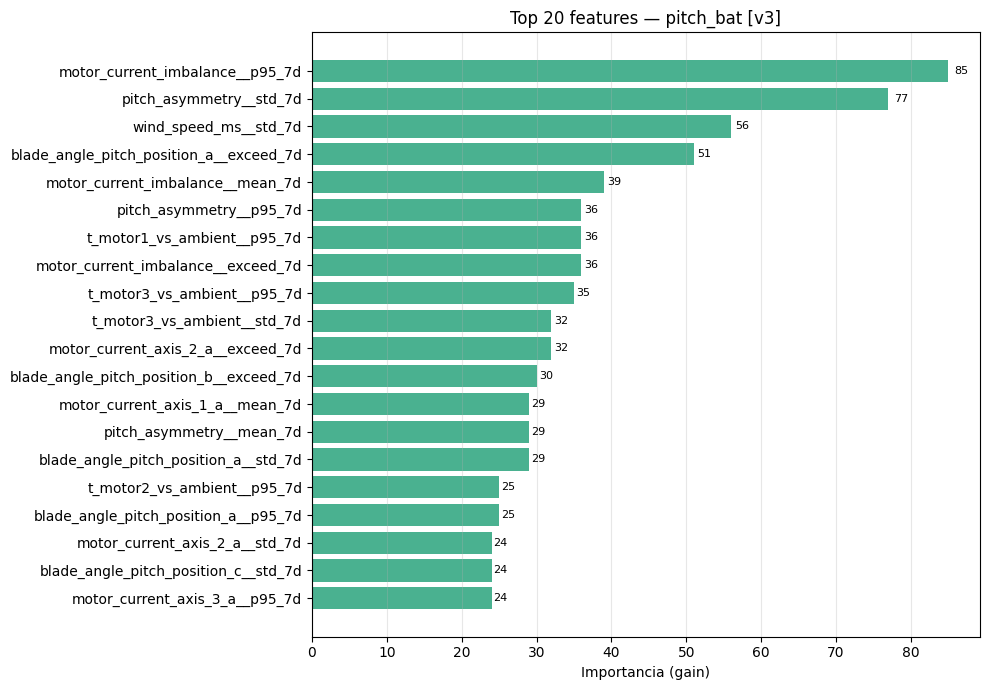

  Guardado: feature_importance_pitch_bat_v3.png


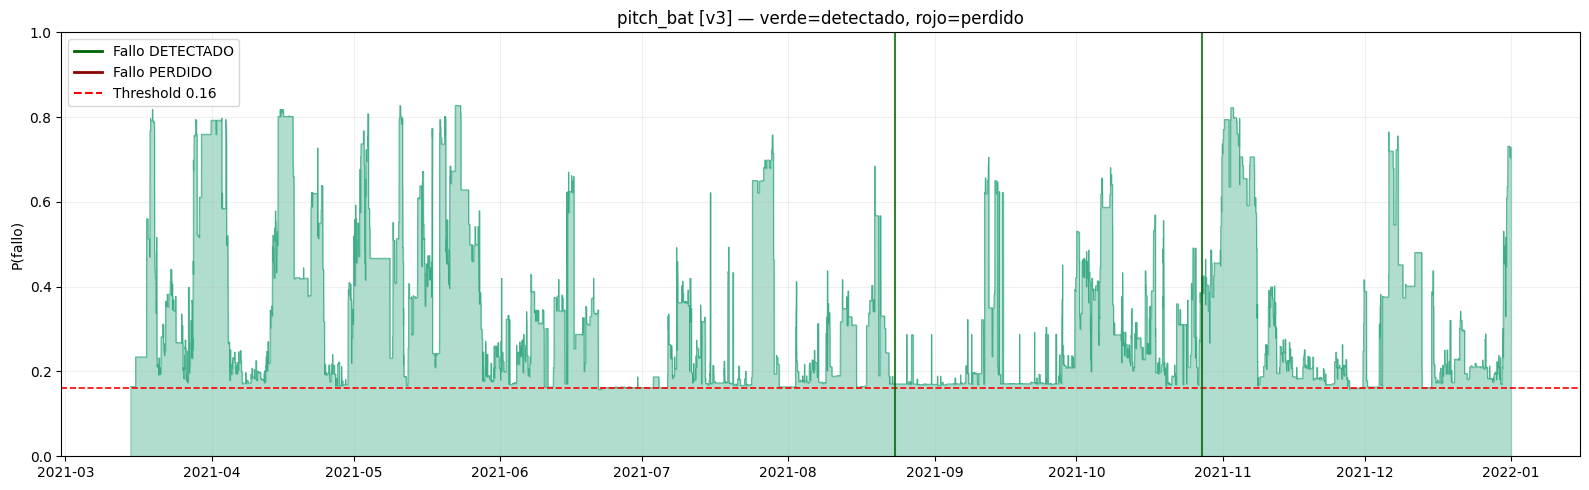

  Guardado: timeline_pitch_bat_v3.png


In [13]:
family = 'pitch_bat'

params_used = LGBM_PARAMS
result_pitchbat = train_family_v3(family, params=params_used)
model_pitchbat, metrics_pitchbat, train_pitchbat, test_pitchbat, X_test_pitchbat, y_test_pitchbat, prob_pitchbat, feats_pitchbat = result_pitchbat

ev_pitchbat = evaluate_by_event(test_pitchbat, prob_pitchbat, family,
                               metrics_pitchbat['threshold'], metrics_pitchbat['lead_hours'])

pickle.dump(model_pitchbat, open(os.path.join(models_dir, f'model_pitch_bat_v3.pkl'), 'wb'))
with open(os.path.join(models_dir, f'results_pitch_bat_v3.json'), 'w') as f:
    json.dump(metrics_pitchbat, f, indent=2)
plot_feature_importance(model_pitchbat, feats_pitchbat, family)
plot_timeline_v3(test_pitchbat, prob_pitchbat, family, metrics_pitchbat['threshold'], ev_pitchbat['details'])


## Resumen Final

In [14]:
all_m = [metrics_yawcable, metrics_generator, metrics_brakehydro, metrics_pitchbat]

print('\n' + '='*75)
print('RESUMEN v3 — MÉTRICAS POR EVENTO (operativamente relevantes)')
print('='*75)
print(f'{"Familia":<15} {"Lead":>5} {"Thr":>5} {"AUC":>6} {"Detectados":>12} {"Total":>7} {"Event R":>8}  {"OK?":<5}')
print('-'*75)
for m in all_m:
    ok = '✅' if m['event_recall'] >= 0.80 else ('⚠️' if m['event_recall'] >= 0.50 else '❌')
    print(f'{m["family"]:<15} {m["lead_hours"]:>5} {m["threshold"]:>5.2f} '
          f'{m["auc_roc"]:>6.3f} {m["events_detected"]:>12} {m["events_total"]:>7} '
          f'{m["event_recall"]:>8.3f}  {ok}')

print()
print('Objetivo: Event Recall > 0.80 (detectar >80% de los fallos reales)')
print()
print('MÉTRICAS POR FILA (referencia):')
print(f'{"Familia":<15} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-'*45)
for m in all_m:
    print(f'{m["family"]:<15} {m["precision_row"]:>10.3f} {m["recall_row"]:>8.3f} {m["f1_row"]:>8.3f}')



RESUMEN v3 — MÉTRICAS POR EVENTO (operativamente relevantes)
Familia          Lead   Thr    AUC   Detectados   Total  Event R  OK?  
---------------------------------------------------------------------------
yaw_cable          72  0.17  0.544           24      24    1.000  ✅
generator         120  0.06  0.642            4       4    1.000  ✅
brake_hydro       120  0.25  0.478            1       3    0.333  ❌
pitch_bat         336  0.16  0.480            2       2    1.000  ✅

Objetivo: Event Recall > 0.80 (detectar >80% de los fallos reales)

MÉTRICAS POR FILA (referencia):
Familia          Precision   Recall       F1
---------------------------------------------
yaw_cable            0.274    1.000    0.430
generator            0.100    0.910    0.180
brake_hydro          0.100    0.200    0.133
pitch_bat            0.100    1.000    0.182
